In [1]:
import pandas as pd
import requests
from io import StringIO
import yfinance as yf
from datetime import datetime
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
START_ANALYSIS_DATE = pd.Timestamp("2007-02-01")
TODAY = pd.Timestamp.today().normalize()
WIKI_URL = "https://en.wikipedia.org/wiki/Nasdaq-100"

In [3]:
# Pobranie HTML (z User-Agent)

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(WIKI_URL, headers=headers)
response.raise_for_status()
tables = pd.read_html(StringIO(response.text))

In [4]:
# Znalezienie tabeli zmian (MultiIndex)

changes_table = None
for tbl in tables:
    if isinstance(tbl.columns, pd.MultiIndex):
        lvl0 = [c[0] for c in tbl.columns]
        if {"Date", "Added", "Removed"}.issubset(set(lvl0)):
            changes_table = tbl.copy()
            break
if changes_table is None:
    raise ValueError("Nie znaleziono tabeli zmian składu NASDAQ-100.")

In [5]:
# Dynamiczne wybranie kolumn

if isinstance(changes_table.columns, pd.MultiIndex):
    date_col = [c for c in changes_table.columns if c[0] == "Date"][0]
    added_col = [c for c in changes_table.columns if c[0] == "Added" and c[1] == "Ticker"][0]
    removed_col = [c for c in changes_table.columns if c[0] == "Removed" and c[1] == "Ticker"][0]
else:
    date_col = [c for c in changes_table.columns if "Date" in str(c)][0]
    added_col = [c for c in changes_table.columns if "Added" in str(c) and "Ticker" in str(c)][0]
    removed_col = [c for c in changes_table.columns if "Removed" in str(c) and "Ticker" in str(c)][0]

changes_table = changes_table[[date_col, added_col, removed_col]].copy()
changes_table.columns = ["date", "added", "removed"]
changes_table["date"] = pd.to_datetime(changes_table["date"])

In [6]:
# Rozbicie tickerów

def split_tickers(x):
    if pd.isna(x):
        return []
    return [t.strip() for t in str(x).split(",") if t.strip()]

records = []
for _, row in changes_table.iterrows():
    date = row["date"]
    for ticker in split_tickers(row["added"]):
        records.append({"ticker": ticker, "date": date, "action": "added"})
    for ticker in split_tickers(row["removed"]):
        records.append({"ticker": ticker, "date": date, "action": "removed"})

events = pd.DataFrame(records)

In [7]:
# Budowa start_date / end_date

records_periods = []

for ticker, group in events.groupby("ticker"):
    group = group.sort_values("date").reset_index(drop=True)
    current_start = None

    for _, row in group.iterrows():
        if row["action"] == "added":
            # rozpoczęcie nowego okresu
            current_start = row["date"]
        elif row["action"] == "removed":
            if current_start is None:
                # spółka była w indeksie na początku analizy
                current_start = START_ANALYSIS_DATE
            # zapis okresu
            records_periods.append({
                "ticker": ticker,
                "start_date": current_start,
                "end_date": row["date"]
            })
            current_start = None

    # jeśli po ostatnim evencie spółka wciąż w indeksie
    if current_start is not None:
        records_periods.append({
            "ticker": ticker,
            "start_date": current_start,
            "end_date": pd.NaT
        })

df_periods = pd.DataFrame(records_periods)

In [8]:
# Ograniczenie dat do okresu analizy

df_periods = df_periods[
    (df_periods["start_date"] <= TODAY) &
    ((df_periods["end_date"].isna()) | (df_periods["end_date"] >= START_ANALYSIS_DATE))
].copy()
df_periods["start_date"] = df_periods["start_date"].clip(lower=START_ANALYSIS_DATE)
df_periods = df_periods.sort_values(["ticker", "start_date"]).reset_index(drop=True)

In [9]:
# Uzupełnienie tickerów z Current Components

current_table = None
for tbl in tables:
    cols = []
    for c in tbl.columns:
        if isinstance(c, tuple):
            cols.append(c[0])
        else:
            cols.append(str(c))
    if "Ticker" in cols and "Company" in cols:
        current_table = tbl.copy()
        break
if current_table is None:
    raise ValueError("Nie znaleziono tabeli Current Components NASDAQ-100.")

# Pobranie tickerów z Current Components
if isinstance(current_table.columns, pd.MultiIndex):
    ticker_col = [c for c in current_table.columns if c[0] == "Ticker"][0]
    current_table["Ticker"] = current_table[ticker_col]
current_tickers = set(current_table["Ticker"].str.strip())
existing_tickers = set(df_periods["ticker"])
new_tickers = current_tickers - existing_tickers

# Dodanie brakujących tickers
new_rows = pd.DataFrame([
    {"ticker": t, "start_date": START_ANALYSIS_DATE, "end_date": pd.NaT}
    for t in new_tickers
])
df_periods = pd.concat([df_periods, new_rows], ignore_index=True)
df_periods = df_periods.sort_values(["ticker", "start_date"]).reset_index(drop=True)

In [10]:
# Zapis finalny CSV

df_periods.to_csv("nasdaq100_constituents.csv", index=False)
print("✅ Zapisano: nasdaq100_constituents.csv")
print(f"Liczba rekordów (okresów): {len(df_periods)}")

✅ Zapisano: nasdaq100_constituents.csv
Liczba rekordów (okresów): 310


In [11]:
END_ANALYSIS_DATE = "2025-12-19"
NASDAQ_PERIODS_CSV = "nasdaq100_constituents.csv"
PERCENT_THRESHOLD = 0.75
BATCH_SIZE = 50

In [12]:
# Wczytanie okresów w których spółki przynależyły do NASDAQ-100

df_periods = pd.read_csv(NASDAQ_PERIODS_CSV, parse_dates=["start_date", "end_date"])
df_periods["end_date"] = pd.to_datetime(df_periods["end_date"], errors="coerce")

tickers_all = df_periods["ticker"].unique().tolist()

In [13]:
tickers_all

['AAL',
 'AAPL',
 'ABNB',
 'ADBE',
 'ADI',
 'ADP',
 'ADSK',
 'AEOS',
 'AEP',
 'AKAM',
 'ALGN',
 'ALNY',
 'ALTR',
 'ALXN',
 'AMAT',
 'AMD',
 'AMGN',
 'AMLN',
 'AMZN',
 'ANSS',
 'APCC',
 'APOL',
 'APP',
 'ARM',
 'ASML',
 'ATVI',
 'AVGO',
 'AXON',
 'AZN',
 'BATRA',
 'BATRK',
 'BBBY',
 'BEAS',
 'BIDU',
 'BIIB',
 'BKNG',
 'BKR',
 'BMC',
 'BMET',
 'BMRN',
 'BRCM',
 'CA',
 'CCEP',
 'CDNS',
 'CDW',
 'CDWC',
 'CEG',
 'CELG',
 'CEPH',
 'CERN',
 'CHKP',
 'CHRW',
 'CHTR',
 'CKFR',
 'CMCSA',
 'CMCSK',
 'CMVT',
 'COST',
 'CPRT',
 'CRWD',
 'CSCO',
 'CSGP',
 'CSX',
 'CTAS',
 'CTRP',
 'CTRX',
 'CTSH',
 'CTXS',
 'DASH',
 'DDOG',
 'DELL',
 'DISCA',
 'DISCK',
 'DISH',
 'DLTR',
 'DOCU',
 'DTV',
 'DXCM',
 'EA',
 'EBAY',
 'ENDP',
 'ENPH',
 'EQIX',
 'ERIC',
 'ESRX',
 'EXC',
 'EXPD',
 'EXPE',
 'FANG',
 'FAST',
 'FB',
 'FER',
 'FFIV',
 'FI',
 'FLEX',
 'FLIR',
 'FMCN',
 'FOSL',
 'FOX',
 'FOXA',
 'FSLR',
 'FTNT',
 'FWLT',
 'GEHC',
 'GENZ',
 'GFS',
 'GILD',
 'GMCR',
 'GOLD',
 'GOOG',
 'GOOGL',
 'GRMN',
 'HANS',
 '

In [14]:
df_periods

,ticker,start_date,end_date
0,AAL,2014-12-22,2020-04-20
1,AAPL,2007-02-01,NaT
2,ABNB,2021-12-20,NaT
3,ADBE,2007-02-01,NaT
4,ADI,2012-12-24,NaT
...,...,...,...
305,XRAY,2007-02-01,2013-12-23
306,XRAY,2016-06-20,2018-11-19
307,YHOO,2007-02-01,2017-06-19
308,ZM,2020-04-30,2023-12-18


In [15]:
# Sprawdzenie dostępności tickerów w Yahoo Finance

available_tickers = []
unavailable_tickers = []

for t in tickers_all:
    try:
        info = yf.Ticker(t).info
        if "regularMarketPrice" in info or "previousClose" in info:
            available_tickers.append(t)
        else:
            unavailable_tickers.append(t)
    except:
        unavailable_tickers.append(t)

print(f"Dostępne tickery: {len(available_tickers)}")
print(f"Niedostępne tickery (zignorowane): {len(unavailable_tickers)}")
print(unavailable_tickers)

HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 


Dostępne tickery: 194
Niedostępne tickery (zignorowane): 79
['AEOS', 'ALTR', 'ALXN', 'AMLN', 'ANSS', 'APCC', 'APOL', 'ATVI', 'BEAS', 'BMC', 'BMET', 'BRCM', 'CDWC', 'CELG', 'CEPH', 'CERN', 'CKFR', 'CMCSK', 'CMVT', 'CTRP', 'CTRX', 'CTXS', 'DISCA', 'DISCK', 'DISH', 'DTV', 'ENDP', 'ESRX', 'FLIR', 'FMCN', 'FWLT', 'GENZ', 'GMCR', 'HANS', 'IACI', 'JNPR', 'JOYG', 'KFT', 'KRFT', 'LEAP', 'LIFE', 'LLTC', 'LMCA', 'LMCK', 'LVLT', 'MXIM', 'MYL', 'NDOI', 'NIHD', 'NLOK', 'NLTI', 'NUAN', 'PDCO', 'PETM', 'PPDI', 'QRTEA', 'RIMM', 'SEPR', 'SGEN', 'SHPG', 'SIAL', 'SPLK', 'SPLS', 'STRZA', 'TCFCA', 'TCFCB', 'TLAB', 'UAUA', 'VIAB', 'VIP', 'VMED', 'WBA', 'WCRX', 'WFM', 'WFMI', 'WLTW', 'XLNX', 'XMSR', 'YHOO']


In [16]:
# Pobranie danych partiami

def download_in_batches(tickers, start, end, batch_size=50):
    all_data = []
    for i in range(0, len(tickers), batch_size):
        batch = tickers[i:i+batch_size]
        data = yf.download(batch, start=start, end=end, group_by="ticker", progress=True)
        all_data.append(data)
    if all_data:
        return pd.concat(all_data, axis=1)
    else:
        return pd.DataFrame()

data = download_in_batches(available_tickers, START_ANALYSIS_DATE, END_ANALYSIS_DATE)

C:\Users\lukas\AppData\Local\Temp\ipykernel_19256\3884130127.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(batch, start=start, end=end, group_by="ticker", progress=True)
[*********************100%***********************]  50 of 50 completed
C:\Users\lukas\AppData\Local\Temp\ipykernel_19256\3884130127.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(batch, start=start, end=end, group_by="ticker", progress=True)
[*********************100%***********************]  50 of 50 completed
C:\Users\lukas\AppData\Local\Temp\ipykernel_19256\3884130127.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(batch, start=start, end=end, group_by="ticker", progress=True)
[*********************100%***********************]  50 of 50 completed
C:\Users\lukas\AppData\Local\Temp\ipykernel_19256\3884130127.py:7: FutureWarning: YF.download() has 

In [17]:
data

Ticker             CEG                                                 \
Price             Open        High         Low       Close     Volume   
Date                                                                    
2007-02-01         NaN         NaN         NaN         NaN        NaN   
2007-02-02         NaN         NaN         NaN         NaN        NaN   
2007-02-05         NaN         NaN         NaN         NaN        NaN   
2007-02-06         NaN         NaN         NaN         NaN        NaN   
2007-02-07         NaN         NaN         NaN         NaN        NaN   
...                ...         ...         ...         ...        ...   
2025-12-12  379.000000  380.779999  351.220001  351.980011  3778600.0   
2025-12-15  356.649994  360.959991  350.670013  357.140015  2628800.0   
2025-12-16  356.059998  368.179993  350.329987  365.625000  2496800.0   
2025-12-17  368.515015  372.000000  334.179993  340.970001  4598000.0   
2025-12-18  351.989990  371.239990  348.779999  361.049988  3773200.0   

Ticker             APP                                                 ...  \
Price             Open        High         Low       Close     Volume  ...   
Date                                                                   ...   
2007-02-01         NaN         NaN         NaN         NaN        NaN  ...   
2007-02-02         NaN         NaN         NaN         NaN        NaN  ...   
2007-02-05         NaN         NaN         NaN         NaN        NaN  ...   
2007-02-06         NaN         NaN         NaN         NaN        NaN  ...   
2007-02-07         NaN         NaN         NaN         NaN        NaN  ...   
...                ...         ...         ...         ...        ...  ...   
2025-12-12  714.280029  716.296997  668.739990  670.669983  4171400.0  ...   
2025-12-15  682.570007  691.900024  661.559998  675.164978  3776100.0  ...   
2025-12-16  668.500000  682.942017  654.000000  677.299988  3233200.0  ...   
2025-12-17  684.590027  688.989990  656.869995  657.130005  2997200.0  ...   
2025-12-18  675.000000  704.130005  674.000000  694.369995  3596900.0  ...   

Ticker             WDC                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2007-02-01   11.859942   11.968749   11.684642   11.751136  4485499   
2007-02-02   11.751135   11.835763   11.636284   11.678597  4201451   
2007-02-05   11.678597   11.696730   11.467027   11.600014  3436096   
2007-02-06   11.648372   11.666506   11.370310   11.539565  2786106   
2007-02-07   11.575838   11.666509   11.503300   11.569793  2752502   
...                ...         ...         ...         ...      ...   
2025-12-12  184.339996  185.820007  170.020004  176.339996  9677900   
2025-12-15  178.289993  180.979996  171.820007  172.039993  5781900   
2025-12-16  172.080002  177.380005  170.740005  174.580002  5857000   
2025-12-17  179.899994  181.669998  165.470001  166.259995  6693100   
2025-12-18  174.800003  181.490005  174.429993  175.009995  9147100   

Ticker            ROST                                               
Price             Open        High         Low       Close   Volume  
Date                                                                 
2007-02-01    6.698258    6.803239    6.655030    6.731193  6344400  
2007-02-02    6.739427    6.784713    6.681789    6.710608  5348400  
2007-02-05    6.700315    6.712666    6.576807    6.589158  3524400  
2007-02-06    6.591219    6.636505    6.562400    6.628271  2877600  
2007-02-07    6.634446    6.700317    6.564458    6.669441  3497600  
...                ...         ...         ...         ...      ...  
2025-12-12  184.139999  185.000000  181.289993  182.089996  2549400  
2025-12-15  183.160004  184.750000  181.770004  184.279999  3118300  
2025-12-16  184.809998  185.850006  182.039993  182.399994  2645100  
2025-12-17  182.539993  183.300003  181.589996  1

In [18]:
# Tworzymy DataFrame tylko z Close

close_data = pd.DataFrame({t: data[t]["Close"] for t in available_tickers if t in data.columns.get_level_values(0)})
close_data = close_data.sort_index()

In [19]:
close_data

,AAL,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,AKAM,ALGN,...,VRTX,WBD,WDAY,WDC,WTW,WYNN,XEL,XRAY,ZM,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2007-02-01,54.669579,2.541441,NaN,38.759998,20.999207,24.181463,44.259998,20.722727,55.509998,16.610001,...,34.799999,7.748257,NaN,11.751136,72.251259,64.261581,11.797505,25.316677,NaN,NaN
2007-02-02,54.660156,2.541741,NaN,38.970001,21.151466,24.430754,44.290001,20.988274,55.549999,16.469999,...,33.730000,7.687978,NaN,11.678597,72.899460,63.843361,11.842772,25.365969,NaN,NaN
2007-02-05,55.065533,2.517448,NaN,38.439999,21.056305,24.485594,44.720001,21.177958,58.180000,16.219999,...,32.520000,7.618424,NaN,11.600014,73.477600,65.350060,11.943340,25.275595,NaN,NaN
2007-02-06,54.971260,2.523746,NaN,38.459999,20.904043,24.331039,43.720001,21.362911,55.150002,16.330000,...,33.090000,7.521049,NaN,11.539565,72.899460,64.582413,12.084149,25.333109,NaN,NaN
2007-02-07,54.754421,2.583729,NaN,38.150002,21.088022,24.306101,42.290001,21.525545,56.950001,16.420000,...,33.080002,7.479317,NaN,11.569793,72.216156,64.462105,12.084149,26.409529,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-12,14.960000,278.279999,128.389999,356.429993,279.320007,266.100006,297.640015,114.129997,85.879997,165.429993,...,452.040009,29.980000,224.490005,176.339996,326.028320,123.660004,74.574409,11.405009,89.519997,236.279999
2025-12-15,15.330000,274.109985,131.809998,351.149994,280.440002,264.950012,294.309998,115.769997,86.529999,162.729996,...,455.709991,29.709999,214.899994,172.039993,329.857727,126.250000,75.140045,11.237433,86.540001,230.309998
2025-12-16,15.990000,274.609985,132.009995,347.890015,278.399994,262.170013,293.980011,114.570000,87.739998,162.889999,...,454.959991,28.900000,216.110001,174.580002,328.850555,126.040001,73.165283,11.207861,87.910004,232.779999


In [20]:
# Funkcja do filtrowania spółek aktywnych w danym dniu

def active_tickers_on_date(date):
    mask = (df_periods["start_date"] <= date) & (
        (df_periods["end_date"].isna()) | (df_periods["end_date"] >= date)
    )
    tickers_today = df_periods.loc[mask, "ticker"].unique().tolist()
    # bierzemy tylko tickery dostępne w Yahoo
    return [t for t in tickers_today if t in available_tickers]

In [21]:
# Analiza dni spadkowych

results = []

for date in close_data.index:
    tickers_today = active_tickers_on_date(date)
    if not tickers_today:
        continue

    closes_today = close_data.loc[date, tickers_today]
    closes_yesterday = close_data.shift(1).loc[date, tickers_today]

    down_today = closes_today < closes_yesterday
    pct_down = down_today.sum() / len(tickers_today)

    if pct_down >= PERCENT_THRESHOLD:
        results.append({"date": date, "pct_down": pct_down})

df_down_days = pd.DataFrame(results)
print(df_down_days.head())
print(f"Liczba dni, w których ≥ {int(PERCENT_THRESHOLD*100)}% spółek spadło: {len(df_down_days)}")

        date  pct_down
0 2007-02-09  0.808824
1 2007-02-27  0.884058
2 2007-03-02  0.826087
3 2007-03-13  0.869565
4 2007-03-28  0.753623
Liczba dni, w których ≥ 75% spółek spadło: 696


In [22]:
# forward_periods w sesjach
forward_periods = {
    "1M": 21,    # ok. 21 sesji
    "3M": 63,    # ok. 63 sesje
    "12M": 252   # ok. 252 sesje
}

forward_results = []

for idx, row in df_down_days.iterrows():
    date = row["date"]
    tickers_today = active_tickers_on_date(date)
    if not tickers_today:
        continue

    closes_today = close_data.loc[date, tickers_today]
    closes_yesterday = close_data.shift(1).loc[date, tickers_today]

    down_today = closes_today < closes_yesterday
    against_today = ~down_today

    # indeks bieżącej daty w close_data
    try:
        date_idx = close_data.index.get_loc(date)
    except KeyError:
        continue

    for ticker in tickers_today:
        close_start = closes_today[ticker]
        if np.isnan(close_start):
            continue

        returns = {}
        for period_name, n_sessions in forward_periods.items():
            future_idx = date_idx + n_sessions
            if future_idx < len(close_data.index):
                close_end = close_data.iloc[future_idx][ticker]
                if not np.isnan(close_end):
                    returns[period_name] = (close_end / close_start - 1) * 100
                else:
                    returns[period_name] = np.nan
            else:
                returns[period_name] = np.nan

        forward_results.append({
            "date": date,
            "ticker": ticker,
            "trend": "down" if down_today[ticker] else "against",
            "1M_return": returns["1M"],
            "3M_return": returns["3M"],
            "12M_return": returns["12M"]
        })

df_forward = pd.DataFrame(forward_results)

# podsumowanie
print(df_forward.head())
print(df_forward.groupby("trend")[["1M_return","3M_return","12M_return"]].mean())

        date ticker trend  1M_return  3M_return  12M_return
0 2007-02-09   AAPL  down   6.160686  30.587240   55.458114
1 2007-02-09   ADBE  down   2.574313  10.668791  -10.191083
2 2007-02-09   ADSK  down -10.708327   3.195803   -6.391606
3 2007-02-09   AKAM  down  -8.297721 -18.625355  -39.458689
4 2007-02-09   AMAT  down   2.345068  10.325092    4.112896
         1M_return  3M_return  12M_return
trend                                    
against   1.471366   4.936779   18.122719
down      1.828347   5.531334   20.083429


In [23]:
# przykład GOOG i NDX
tickers = ["GOOG", "^NDX"]
ANALYSIS_DAY = pd.Timestamp("2025-12-22")
START_3M = TODAY - pd.Timedelta(days=108) 

data = yf.download(
    tickers,
    start=START_3M,
    end=ANALYSIS_DAY + pd.Timedelta(days=1),
    interval="1d",
    auto_adjust=True,
    progress=False
)["Close"]

In [24]:
returns_from_start = (data / data.iloc[0] - 1) * 100

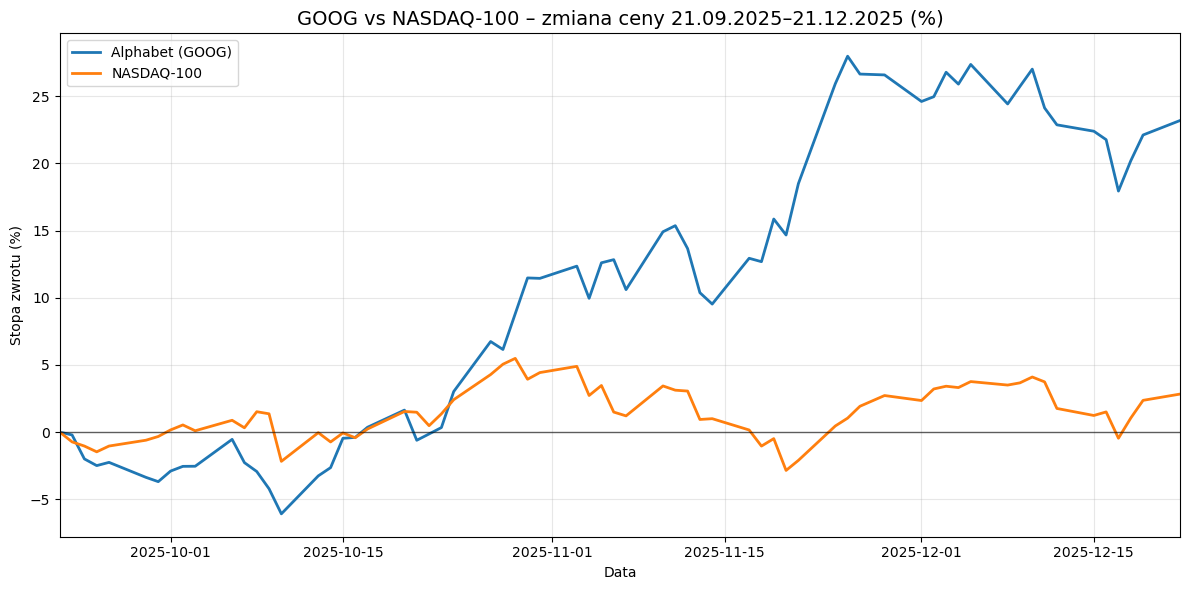

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(
    returns_from_start.index,
    returns_from_start["GOOG"],
    label="Alphabet (GOOG)",
    linewidth=2
)

plt.plot(
    returns_from_start.index,
    returns_from_start["^NDX"],
    label="NASDAQ-100",
    linewidth=2
)

plt.axhline(0, color="black", linewidth=1, alpha=0.6)

plt.title(
    "GOOG vs NASDAQ-100 – zmiana ceny 21.09.2025–21.12.2025 (%)",
    fontsize=14
)
plt.ylabel("Stopa zwrotu (%)")
plt.xlabel("Data")

plt.xlim(returns_from_start.index.min(), returns_from_start.index.max())

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

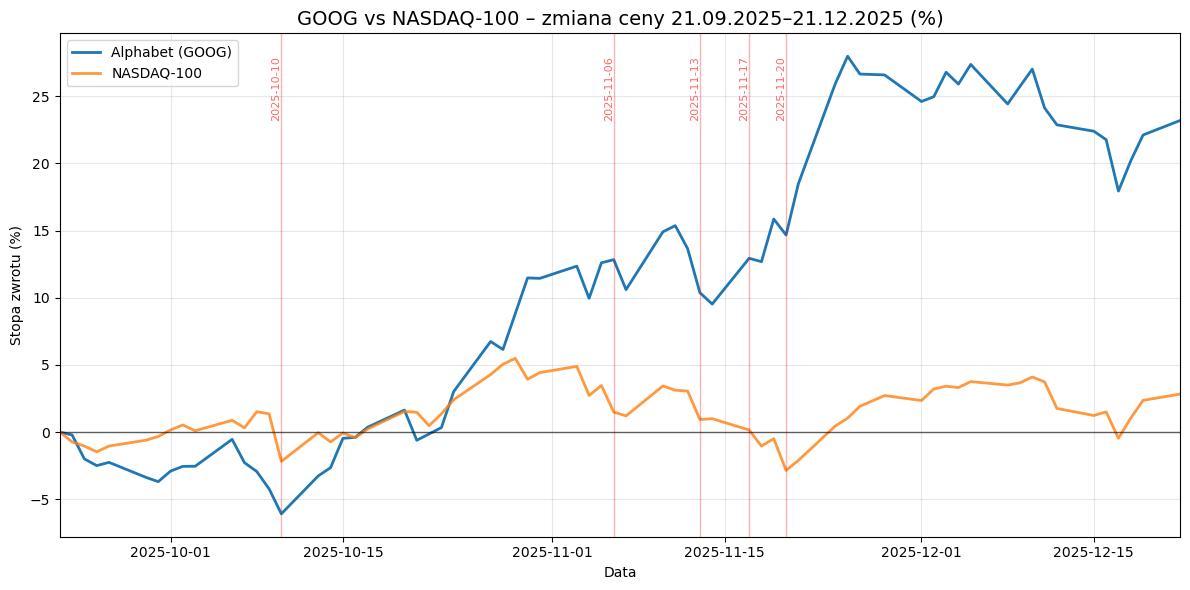

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    returns_from_start.index,
    returns_from_start["GOOG"],
    label="Alphabet (GOOG)",
    linewidth=2
)

ax.plot(
    returns_from_start.index,
    returns_from_start["^NDX"],
    label="NASDAQ-100",
    linewidth=2,
    alpha=0.8
)

y_top = returns_from_start.max().max()

for d in df_down_days["date"]:
    if d in returns_from_start.index:
        ax.axvline(
            x=d,
            color="red",
            alpha=0.3,
            linewidth=1
        )

        ax.text(
            d,
            y_top,
            d.strftime("%Y-%m-%d"),
            rotation=90,
            fontsize=8,
            color="red",
            alpha=0.6,
            ha="right",
            va="top"
        )

ax.axhline(0, color="black", linewidth=1, alpha=0.6)

ax.set_title(
    "GOOG vs NASDAQ-100 – zmiana ceny 21.09.2025–21.12.2025 (%)",
    fontsize=14
)
ax.set_ylabel("Stopa zwrotu (%)")
ax.set_xlabel("Data")

ax.set_xlim(
    returns_from_start.index.min(),
    returns_from_start.index.max()
)

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [27]:
df_down_days.head(-1)

,date,pct_down
0,2007-02-09,0.808824
1,2007-02-27,0.884058
2,2007-03-02,0.826087
3,2007-03-13,0.869565
4,2007-03-28,0.753623
...,...,...
690,2025-09-02,0.776699
691,2025-10-10,0.873786
692,2025-11-06,0.846154
693,2025-11-13,0.786408


         1M_return_mean  1M_return_median  1M_return_std  \
trend                                                      
against        1.471366          1.252513      11.509455   
down           1.828347          1.817829      11.534422   

         1M_return_<lambda_0>  1M_return_<lambda_1>  3M_return_mean  \
trend                                                                 
against             -4.207996              6.688014        4.936779   
down                -4.284726              7.773334        5.531334   

         3M_return_median  3M_return_std  3M_return_<lambda_0>  \
trend                                                            
against          3.577757      20.551483             -5.988502   
down             4.985887      19.361415             -5.195691   

         3M_return_<lambda_1>  12M_return_mean  12M_return_median  \
trend                                                               
against             13.868318        18.122719          12.959135   
do

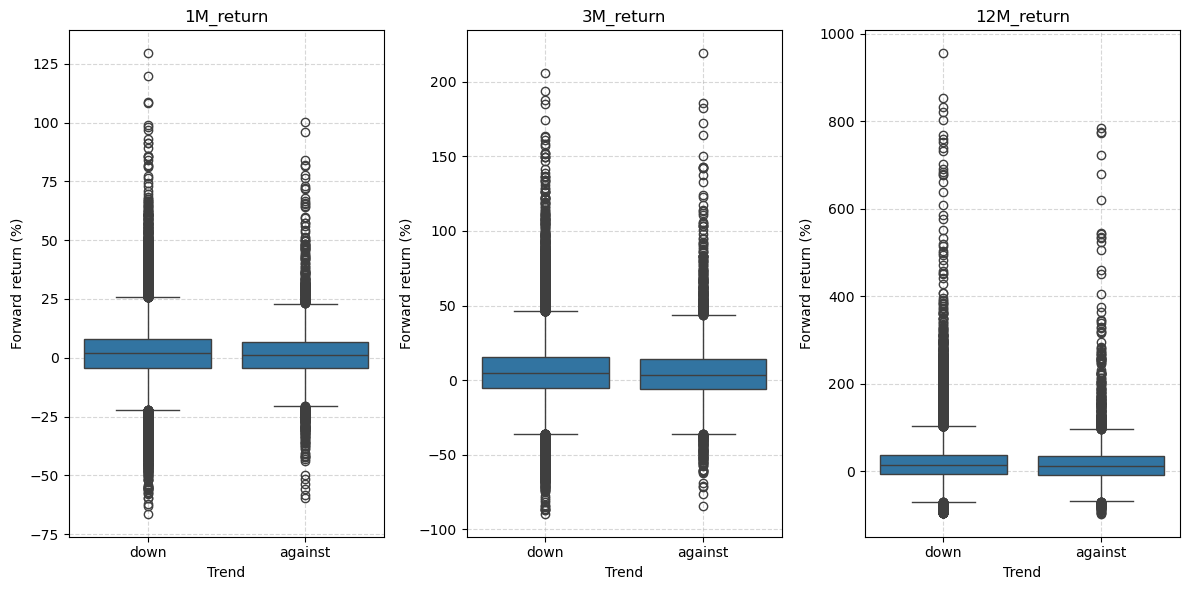

In [28]:
# Agregacja: średnia, mediana, percentyle
summary = df_forward.groupby("trend")[["1M_return","3M_return","12M_return"]].agg(
    ["mean","median","std", lambda x: np.percentile(x.dropna(), 25), lambda x: np.percentile(x.dropna(), 75)]
)
summary.columns = ["_".join(col).strip() for col in summary.columns.values]
print(summary)

# Wykres: boxplot forward returns
plt.figure(figsize=(12,6))

for i, period in enumerate(["1M_return","3M_return","12M_return"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(x="trend", y=period, data=df_forward)
    plt.title(period)
    plt.ylabel("Forward return (%)")
    plt.xlabel("Trend")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [29]:
START_DATE = "2007-02-01"
END_DATE = "2025-12-19"

# Pobranie danych NASDAQ-100

ndx = yf.download(
    "^NDX",
    start=START_DATE,
    end=END_DATE,
    progress=False
)

# spłaszczamy dane
ndx_close = ndx["Close"]

if isinstance(ndx_close, pd.DataFrame):
    ndx_close = ndx_close.iloc[:, 0]

ndx_close = ndx_close.dropna()

C:\Users\lukas\AppData\Local\Temp\ipykernel_19256\404751557.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ndx = yf.download(


In [30]:
type(ndx_close)

pandas.core.series.Series

In [31]:
# Forward returns liczone po sesjach

forward_periods = {
    "1M": 21,
    "3M": 63,
    "12M": 252
}

ndx_results = []

for i in range(len(ndx_close)):
    start_price = ndx_close.iloc[i]
    date = ndx_close.index[i]

    row = {"date": date}

    for label, n_sessions in forward_periods.items():
        future_idx = i + n_sessions
        if future_idx < len(ndx_close):
            end_price = ndx_close.iloc[future_idx]
            row[f"{label}_return"] = (end_price / start_price - 1) * 100
        else:
            row[f"{label}_return"] = np.nan

    ndx_results.append(row)

df_ndx_forward = pd.DataFrame(ndx_results)

In [32]:
df_ndx_forward

,date,1M_return,3M_return,12M_return
0,2007-02-01,-4.382484,5.815963,3.562481
1,2007-02-02,-3.060403,5.426190,1.705663
2,2007-02-05,-3.302349,5.601565,-1.219792
3,2007-02-06,-2.600582,5.954619,-2.906211
4,2007-02-07,-3.656090,5.229304,-3.183407
...,...,...,...,...
4747,2025-12-12,NaN,NaN,NaN
4748,2025-12-15,NaN,NaN,NaN
4749,2025-12-16,NaN,NaN,NaN
4750,2025-12-17,NaN,NaN,NaN


In [33]:
ndx_stats = df_ndx_forward[["1M_return","3M_return","12M_return"]].agg(
    ["mean", "median", "std",
     lambda x: np.percentile(x.dropna(), 25),
     lambda x: np.percentile(x.dropna(), 75)]
)

ndx_stats.index = ["mean", "median", "std", "p25", "p75"]
print(ndx_stats)

        1M_return  3M_return  12M_return
mean     1.340530   4.069930   16.671506
median   2.000246   5.091069   19.117611
std      5.630160   9.518790   20.546615
p25     -1.525962  -0.403202    5.557060
p75      4.828166   9.511735   29.410121


In [34]:
# Średnie forward returns dla grup


down_vs_against = (
    df_forward
    .groupby("trend")[["1M_return", "3M_return", "12M_return"]]
    .mean()
)


# Dodanie benchmarku NASDAQ-100


benchmark_row = pd.DataFrame(
    [ndx_stats.loc["mean"].values],
    columns=down_vs_against.columns,
    index=["NASDAQ-100"]
)

final_table = pd.concat([benchmark_row, down_vs_against])

# Zaokrąglenie do 2 miejsc po przecinku
final_table = final_table.round(2)

print(final_table)

            1M_return  3M_return  12M_return
NASDAQ-100       1.34       4.07       16.67
against          1.47       4.94       18.12
down             1.83       5.53       20.08


In [35]:
# Dołączenie informacji o sile wyprzedaży (pct_down)

df_plot = df_forward.merge(
    df_down_days[["date", "pct_down"]],
    on="date",
    how="left"
)

# zamiana na %
df_plot["pct_down"] = df_plot["pct_down"] * 100

In [36]:
df_plot

,date,ticker,trend,1M_return,3M_return,12M_return,pct_down
0,2007-02-09,AAPL,down,6.160686,30.587240,55.458114,80.882353
1,2007-02-09,ADBE,down,2.574313,10.668791,-10.191083,80.882353
2,2007-02-09,ADSK,down,-10.708327,3.195803,-6.391606,80.882353
3,2007-02-09,AKAM,down,-8.297721,-18.625355,-39.458689,80.882353
4,2007-02-09,AMAT,down,2.345068,10.325092,4.112896,80.882353
...,...,...,...,...,...,...,...
56157,2025-11-20,VRTX,against,NaN,NaN,NaN,88.349515
56158,2025-11-20,WBD,down,NaN,NaN,NaN,88.349515
56159,2025-11-20,WDAY,down,NaN,NaN,NaN,88.349515
56160,2025-11-20,XEL,down,NaN,NaN,NaN,88.349515


In [37]:
df_extreme = df_plot[df_plot["pct_down"] >= 95]

summary = df_extreme[["1M_return", "3M_return", "12M_return"]].agg(["mean", "median"])

print(summary)

        1M_return  3M_return  12M_return
mean     1.917646   9.707746   28.990049
median   2.132802   7.911591   22.464228


In [38]:
color_map = {
    "down": "red",
    "against": "green"
}

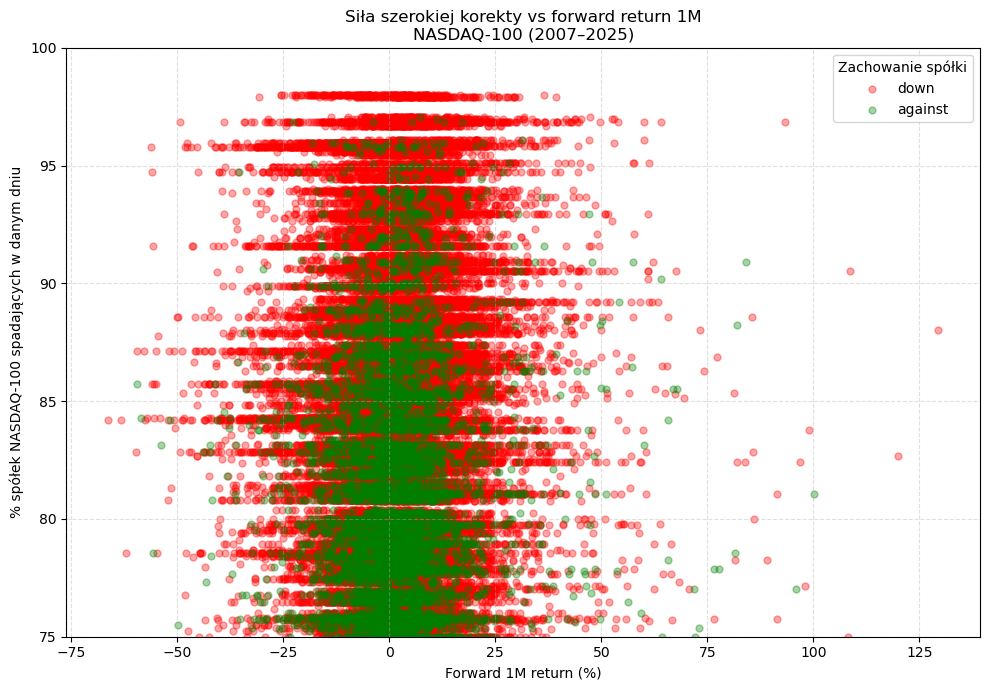

In [39]:
plt.figure(figsize=(10, 7))

for trend, color in color_map.items():
    subset = df_plot[df_plot["trend"] == trend]

    plt.scatter(
        subset["1M_return"],
        subset["pct_down"],
        alpha=0.35,
        s=25,
        c=color,
        label=trend
    )

plt.xlabel("Forward 1M return (%)")
plt.ylabel("% spółek NASDAQ-100 spadających w danym dniu")
plt.title("Siła szerokiej korekty vs forward return 1M\nNASDAQ-100 (2007–2025)")

plt.ylim(75, 100)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Zachowanie spółki")

plt.tight_layout()
plt.show()

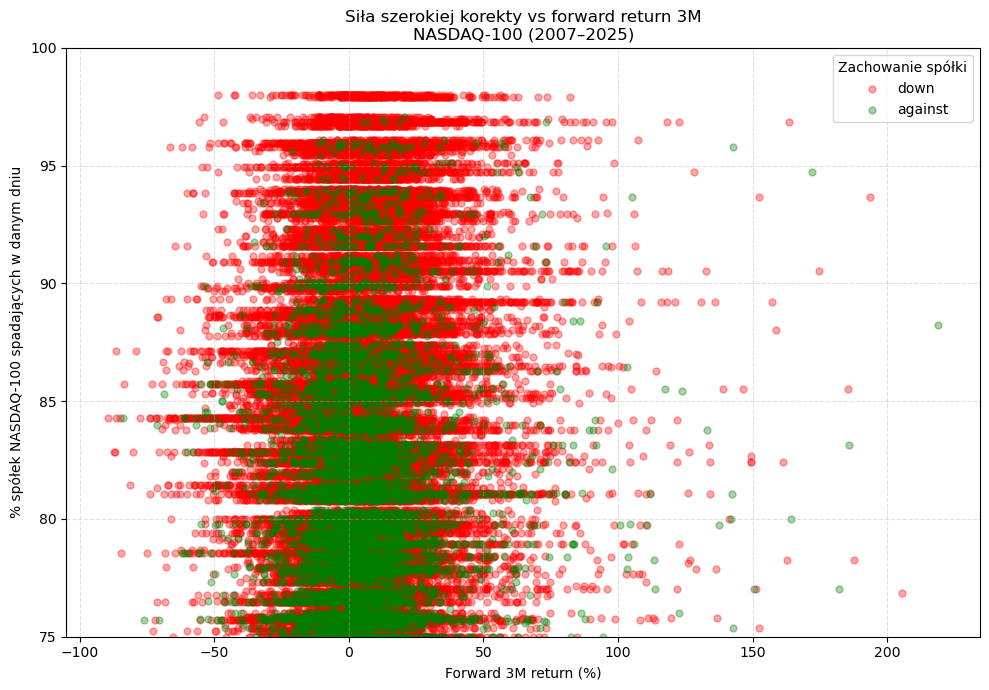

In [40]:
def plot_scatter_forward(df, return_col, title):
    plt.figure(figsize=(10, 7))

    for trend, color in {"down": "red", "against": "green"}.items():
        subset = df[df["trend"] == trend]

        plt.scatter(
            subset[return_col],
            subset["pct_down"],
            alpha=0.35,
            s=25,
            c=color,
            label=trend
        )

    plt.xlabel(f"Forward {return_col.replace('_', ' ')} (%)")
    plt.ylabel("% spółek NASDAQ-100 spadających w danym dniu")
    plt.title(title)

    plt.ylim(75, 100)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="Zachowanie spółki")

    plt.tight_layout()
    plt.show()

plot_scatter_forward(
    df_plot,
    return_col="3M_return",
    title="Siła szerokiej korekty vs forward return 3M\nNASDAQ-100 (2007–2025)"
)

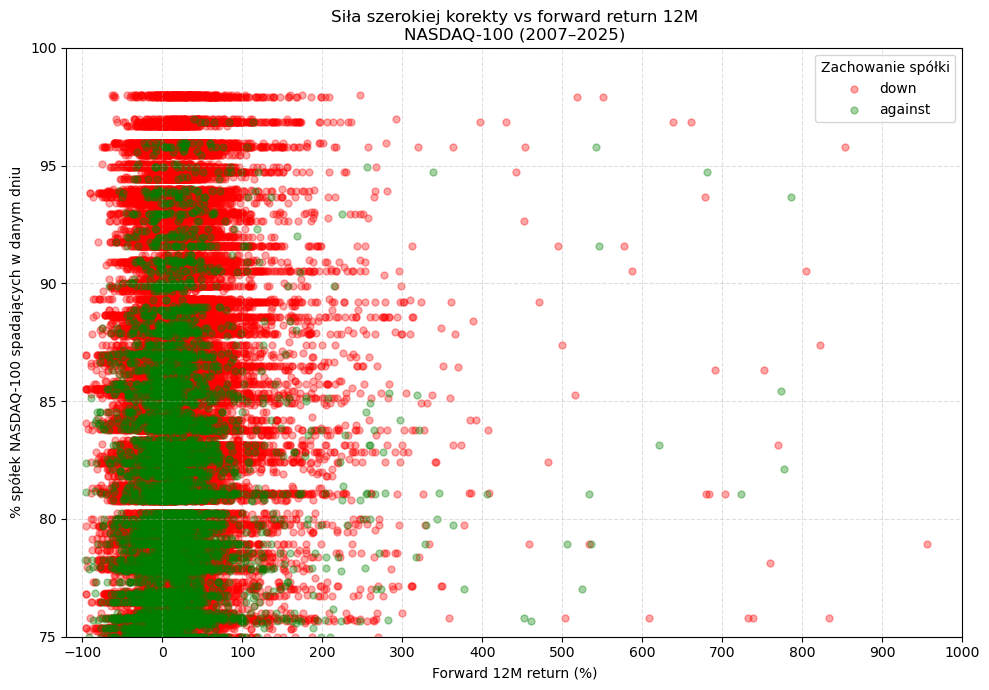

In [41]:
def plot_scatter_forward(
    df,
    return_col,
    title
):
    plt.figure(figsize=(10, 7))

    for trend, color in {"down": "red", "against": "green"}.items():
        subset = df[df["trend"] == trend]

        plt.scatter(
            subset[return_col],
            subset["pct_down"],
            alpha=0.35,
            s=25,
            c=color,
            label=trend
        )

    plt.xlabel(f"Forward {return_col.replace('_', ' ')} (%)")
    plt.ylabel("% spółek NASDAQ-100 spadających w danym dniu")
    plt.title(title)

    # OSIE
    plt.xlim(-120, 1000)
    plt.ylim(75, 100)

    # SIATKA CO 100 pp
    plt.xticks(np.arange(-100, 1001, 100))

    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="Zachowanie spółki")

    plt.tight_layout()
    plt.show()

plot_scatter_forward(
    df_plot,
    return_col="12M_return",
    title="Siła szerokiej korekty vs forward return 12M\nNASDAQ-100 (2007–2025)"
)

In [42]:
def up_down_stats(df, return_col):
    summary = (
        df
        .assign(
            up=lambda x: x[return_col] > 0
        )
        .groupby("trend")["up"]
        .agg(
            total="count",
            up_cases="sum"
        )
    )

    summary["down_cases"] = summary["total"] - summary["up_cases"]
    summary["up_pct"] = (summary["up_cases"] / summary["total"] * 100).round(2)

    return summary

In [43]:
stats_1M = up_down_stats(df_plot, "1M_return")
print("1M\n", stats_1M)

1M
          total  up_cases  down_cases  up_pct
trend                                       
against   6044      3391        2653   56.11
down     50118     29121       20997   58.10


In [44]:
stats_3M = up_down_stats(df_plot, "3M_return")
print("3M\n", stats_3M)

3M
          total  up_cases  down_cases  up_pct
trend                                       
against   6044      3557        2487   58.85
down     50118     31357       18761   62.57


In [45]:
stats_12M = up_down_stats(df_plot, "12M_return")
print("12M\n", stats_12M)

12M
          total  up_cases  down_cases  up_pct
trend                                       
against   6044      3677        2367   60.84
down     50118     32820       17298   65.49


In [46]:
periods = ["1M", "3M", "12M"]
rows = []

for p in periods:
    col = f"{p}_return"
    stats = (
        df_plot
        .assign(up=lambda x: x[col] > 0)
        .groupby("trend")["up"]
        .mean()
        .reset_index()
    )
    stats["period"] = p
    stats["up_pct"] = stats["up"] * 100
    rows.append(stats[["trend", "period", "up_pct"]])

df_hit = pd.concat(rows, ignore_index=True)

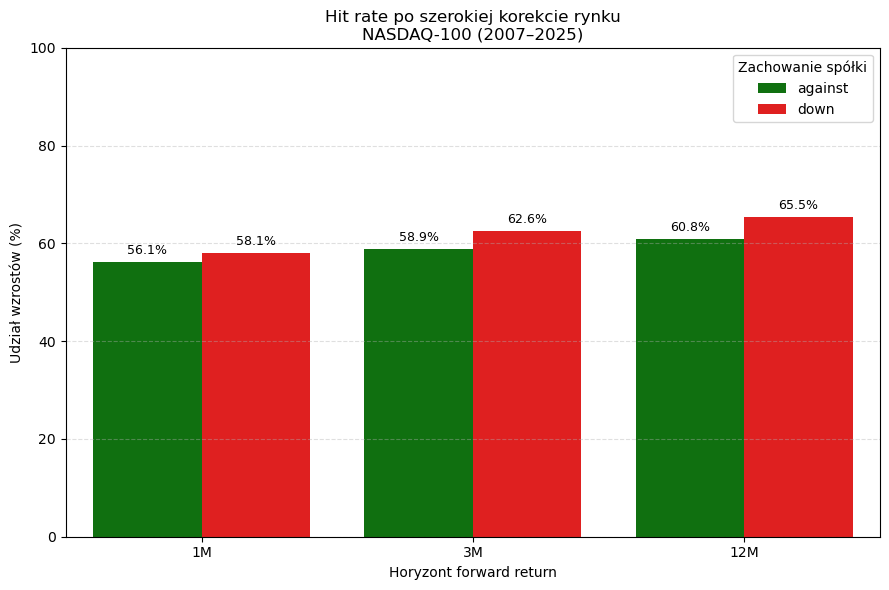

In [47]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=df_hit,
    x="period",
    y="up_pct",
    hue="trend",
    palette={"down": "red", "against": "green"}
)

plt.ylabel("Udział wzrostów (%)")
plt.xlabel("Horyzont forward return")
plt.title("Hit rate po szerokiej korekcie rynku\nNASDAQ-100 (2007–2025)")

plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Zachowanie spółki")

# Dodawanie wartości procentowych na słupkach
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height + 1,  # przesunięcie nad słupkiem
            s=f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [48]:
df_down_days

,date,pct_down
0,2007-02-09,0.808824
1,2007-02-27,0.884058
2,2007-03-02,0.826087
3,2007-03-13,0.869565
4,2007-03-28,0.753623
...,...,...
691,2025-10-10,0.873786
692,2025-11-06,0.846154
693,2025-11-13,0.786408
694,2025-11-17,0.776699


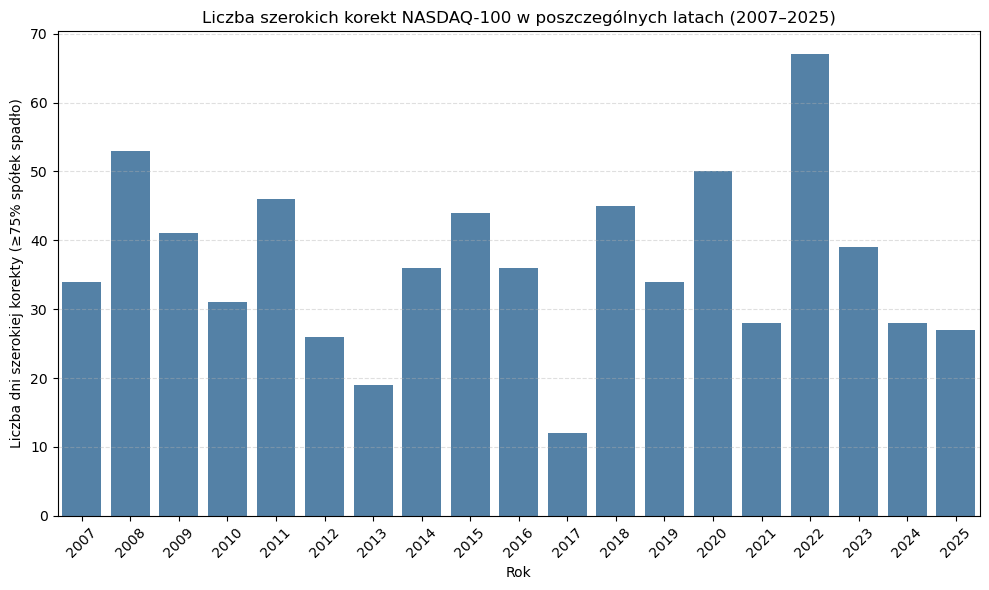

In [49]:
# Wyciągamy rok
df_down_days["year"] = df_down_days["date"].dt.year

# Zliczamy liczbę dni korekt w każdym roku
corrections_per_year = df_down_days.groupby("year").size().reset_index(name="num_corrections")

# Wykres słupkowy
plt.figure(figsize=(10, 6))
sns.barplot(
    data=corrections_per_year,
    x="year",
    y="num_corrections",
    color="steelblue"
)

plt.xlabel("Rok")
plt.ylabel("Liczba dni szerokiej korekty (≥75% spółek spadło)")
plt.title("Liczba szerokich korekt NASDAQ-100 w poszczególnych latach (2007–2025)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

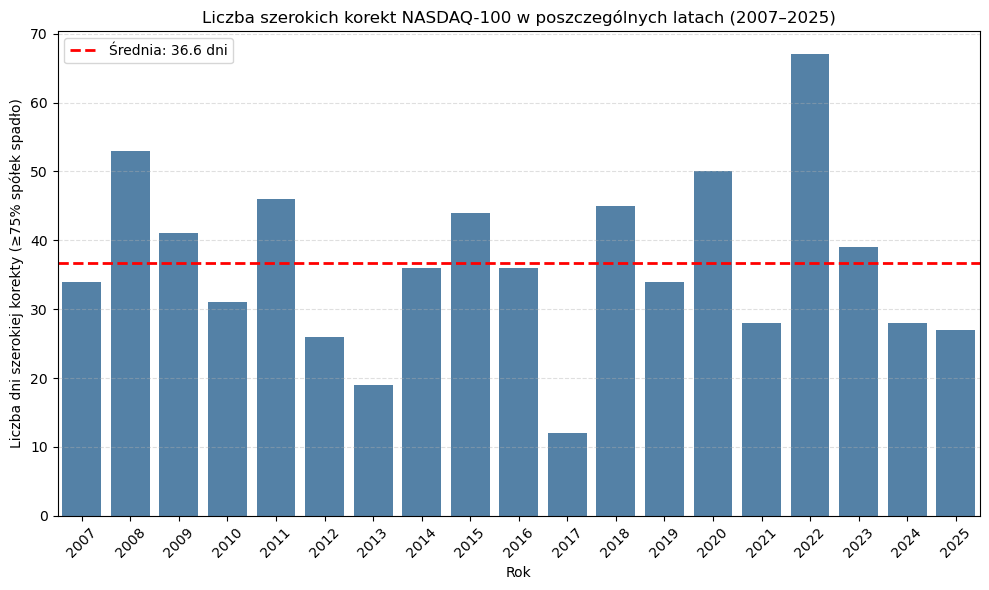

In [50]:
mean_corrections = corrections_per_year["num_corrections"].mean()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=corrections_per_year,
    x="year",
    y="num_corrections",
    color="steelblue"
)

# Linia średniej
plt.axhline(
    mean_corrections,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Średnia: {mean_corrections:.1f} dni"
)

plt.xlabel("Rok")
plt.ylabel("Liczba dni szerokiej korekty (≥75% spółek spadło)")
plt.title("Liczba szerokich korekt NASDAQ-100 w poszczególnych latach (2007–2025)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend()
plt.tight_layout()
plt.show()

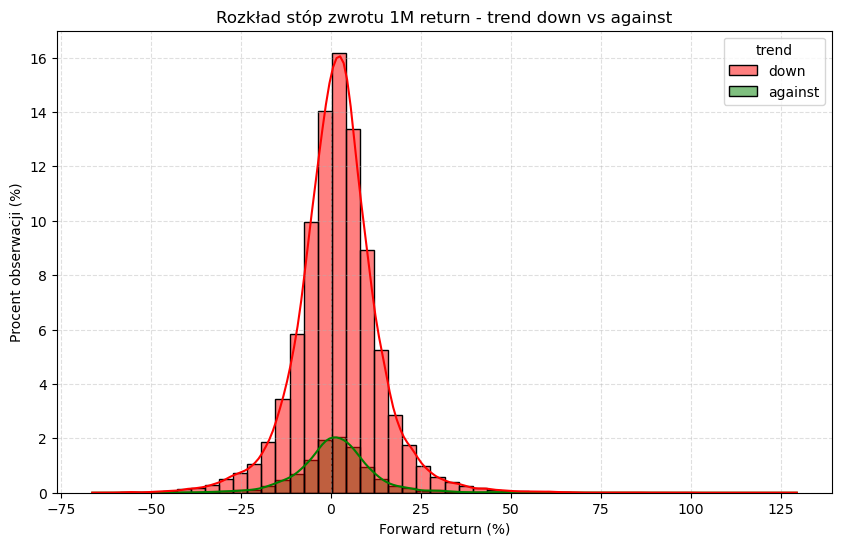

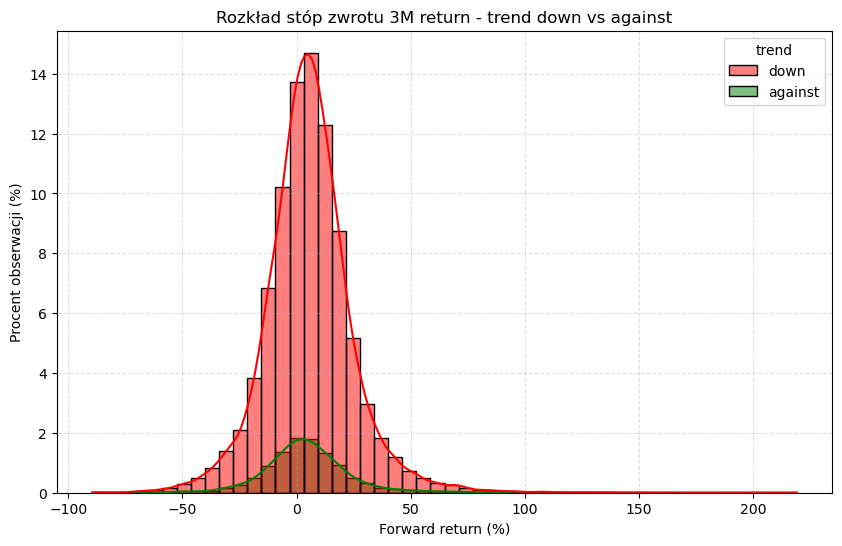

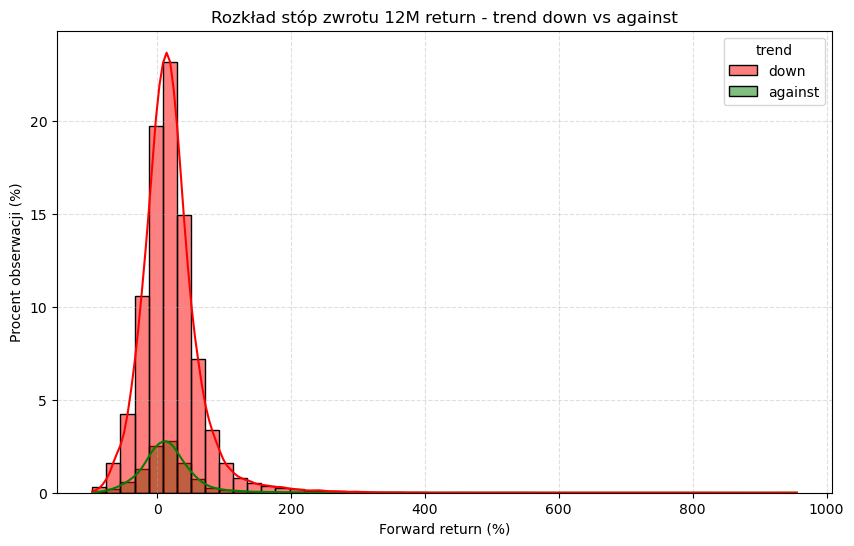

In [51]:
forward_periods = ["1M_return", "3M_return", "12M_return"]

for col in forward_periods:
    plt.figure(figsize=(10,6))
    sns.histplot(
        data=df_plot,
        x=col,
        hue="trend",
        kde=True,
        bins=50,
        palette={"down": "red", "against": "green"},
        alpha=0.5,
        stat="percent"   # <-- procent obserwacji
    )
    plt.title(f"Rozkład stóp zwrotu {col.replace('_', ' ')} - trend down vs against")
    plt.xlabel("Forward return (%)")
    plt.ylabel("Procent obserwacji (%)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

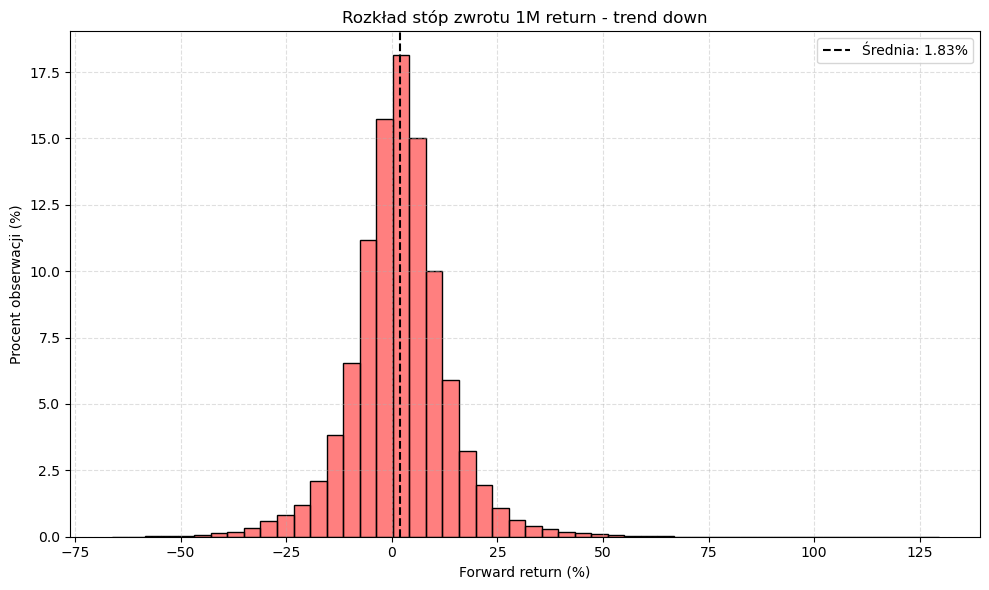

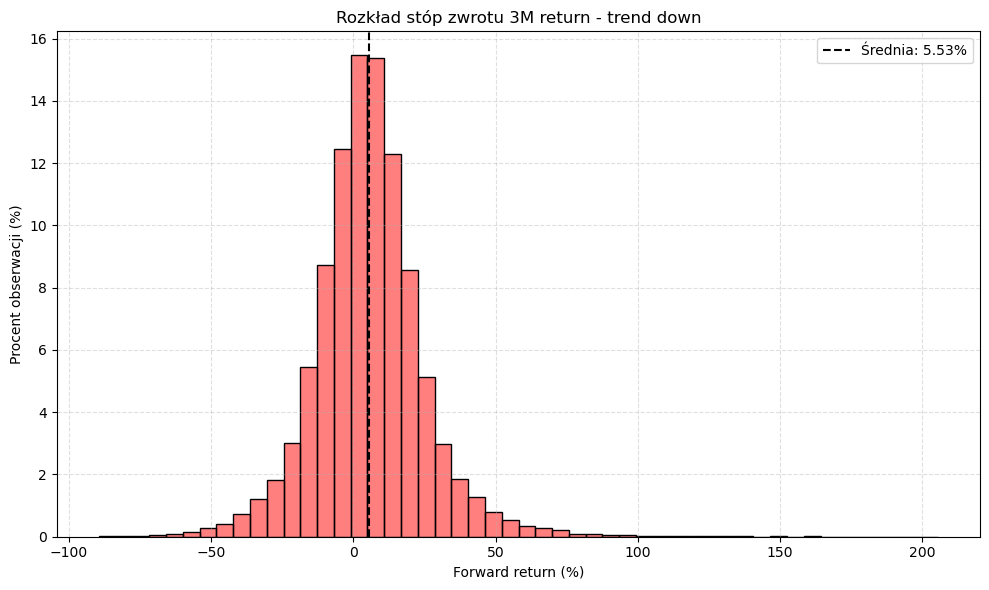

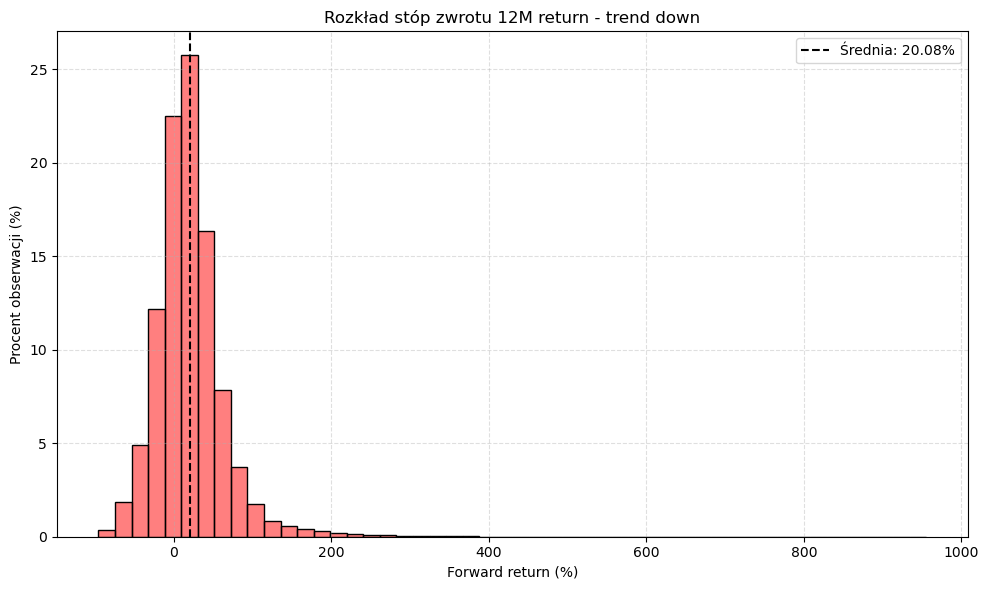

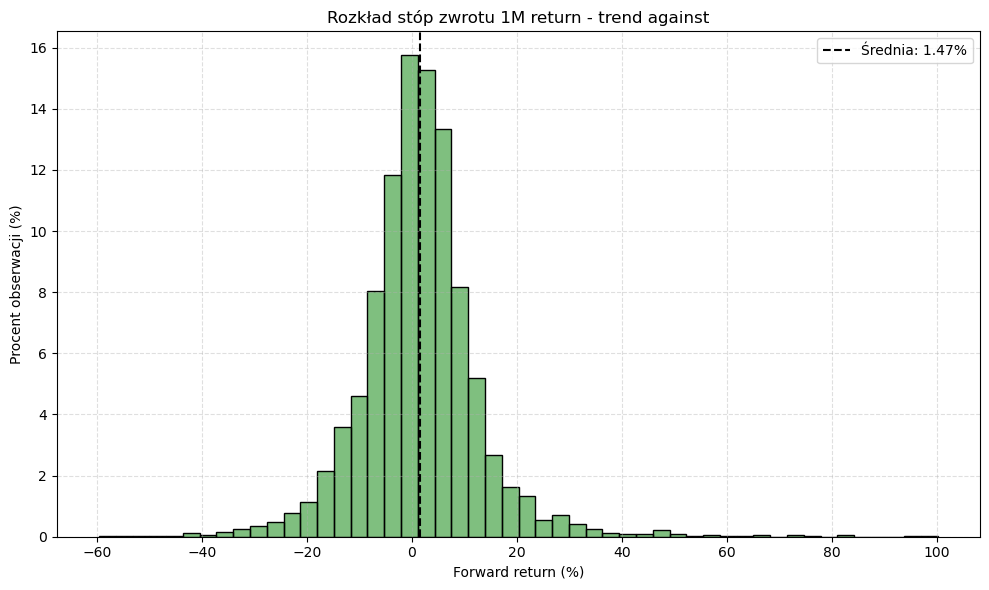

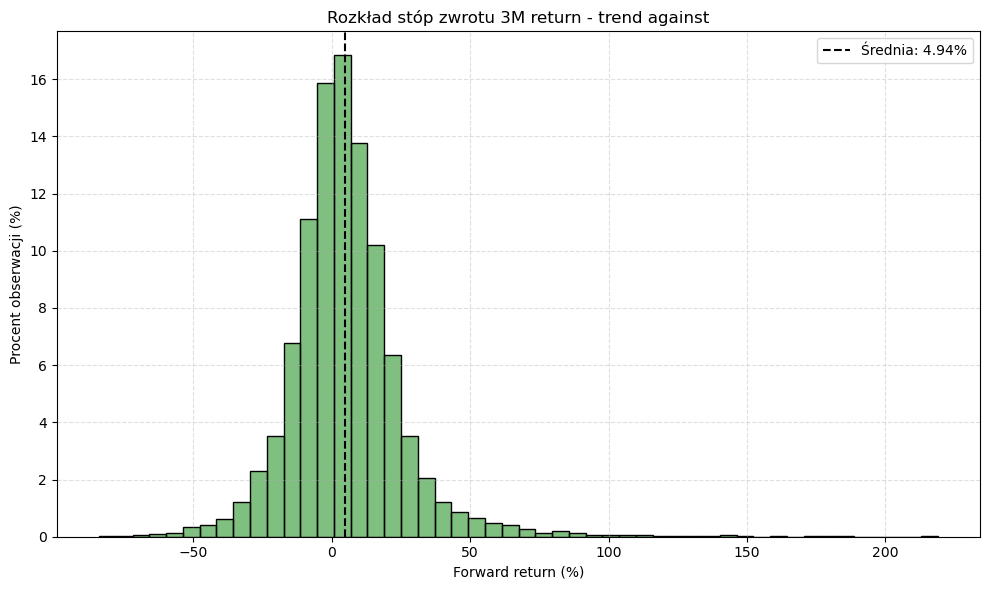

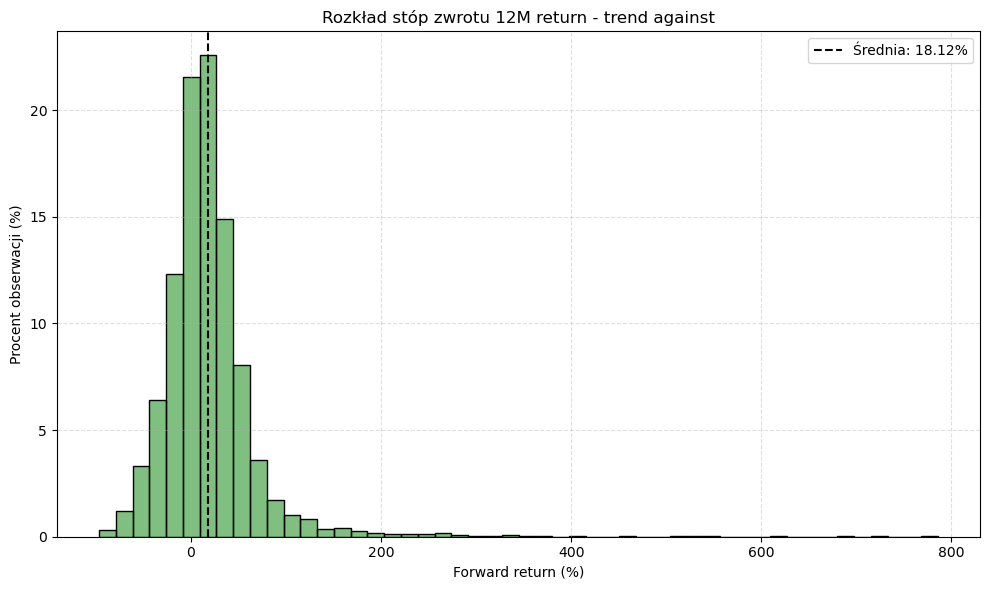

In [52]:
forward_periods = ["1M_return", "3M_return", "12M_return"]
trends = ["down", "against"]

for trend in trends:
    for col in forward_periods:
        plt.figure(figsize=(10,6))
        sns.histplot(
            data=df_plot[df_plot["trend"] == trend],
            x=col,
            kde=False,
            bins=50,
            color="red" if trend=="down" else "green",
            alpha=0.5,
            stat="percent"
        )
        # średnia stopa zwrotu jako pionowa linia
        mean_val = df_plot[df_plot["trend"] == trend][col].mean()
        plt.axvline(x=mean_val, color='black', linestyle='--', linewidth=1.5, label=f"Średnia: {mean_val:.2f}%")
        
        plt.title(f"Rozkład stóp zwrotu {col.replace('_',' ')} - trend {trend}")
        plt.xlabel("Forward return (%)")
        plt.ylabel("Procent obserwacji (%)")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [53]:
# 1M: bardziej skupione koszyki
bins_1M = [-50, -25, 0, 25, 50, np.inf]
labels_1M = ["-50% do -25%", "-25% do 0%", "0% do 25%", "25% do 50%", "> 50%"]

# 3M: ograniczone koszyki
bins_3M = [-75, -50, -25, 0, 25, 50, 75, np.inf]
labels_3M = ["-75% do -50%", "-50% do -25%", "-25% do 0%", "0% do 25%", "25% do 50%", "50% do 75%", "> 75%"]

# 12M: pełne koszyki
bins_12M = [-100, -75, -50, -25, 0, 25, 50, 75, 100, np.inf]
labels_12M = ["-100% do -75%", "-75% do -50%", "-50% do -25%", "-25% do 0%",
              "0% do 25%", "25% do 50%", "50% do 75%", "75% do 100%", "> 100%"]

bins_dict = {"1M_return": (bins_1M, labels_1M),
             "3M_return": (bins_3M, labels_3M),
             "12M_return": (bins_12M, labels_12M)}

In [54]:
for col in ["1M_return", "3M_return", "12M_return"]:
    bins, labels = bins_dict[col]
    df_plot[f"{col}_bin"] = pd.cut(df_plot[col], bins=bins, labels=labels, include_lowest=True)

In [55]:
hist_data = []

for col in ["1M_return", "3M_return", "12M_return"]:
    temp = (
        df_plot.groupby([f"{col}_bin", "trend"])
        .size()
        .reset_index(name="count")
    )
    # liczymy procent w stosunku do sumy dla danego trendu
    temp["percent"] = temp["count"] / temp.groupby("trend")["count"].transform("sum") * 100
    temp["period"] = col
    hist_data.append(temp)

df_hist = pd.concat(hist_data, ignore_index=True)

C:\Users\lukas\AppData\Local\Temp\ipykernel_19256\4103557350.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot.groupby([f"{col}_bin", "trend"])
C:\Users\lukas\AppData\Local\Temp\ipykernel_19256\4103557350.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot.groupby([f"{col}_bin", "trend"])
C:\Users\lukas\AppData\Local\Temp\ipykernel_19256\4103557350.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_

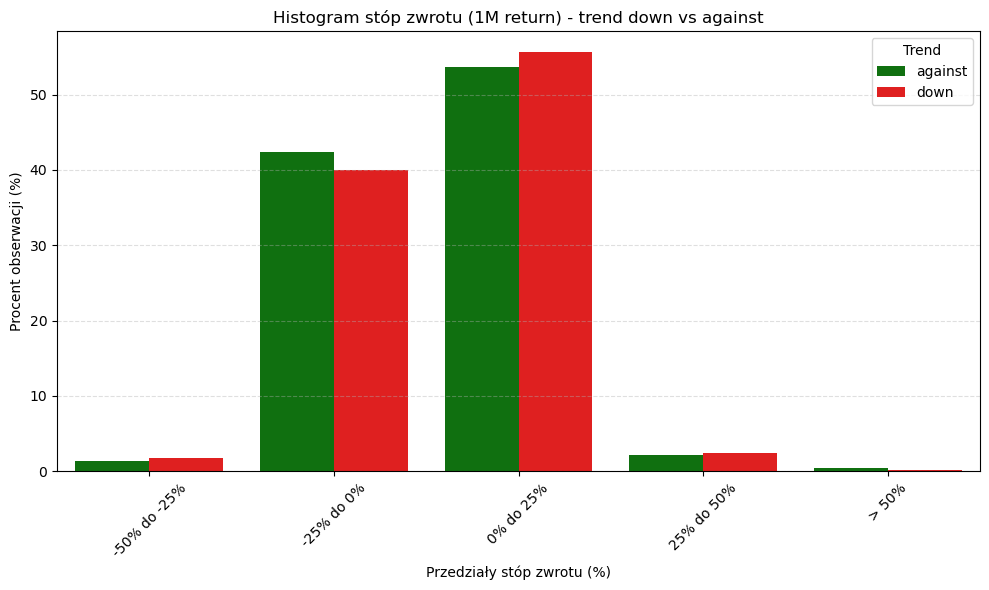

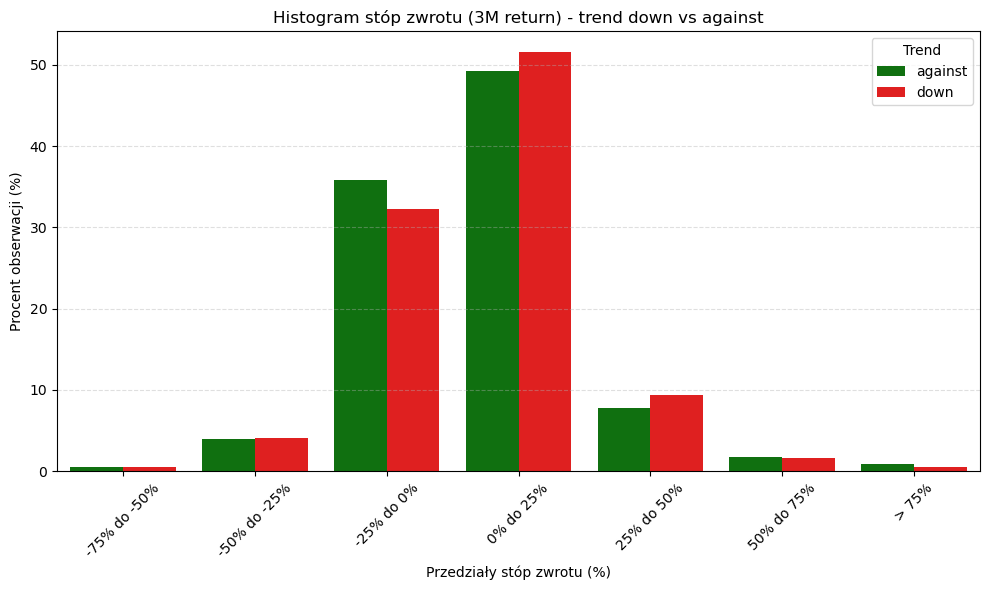

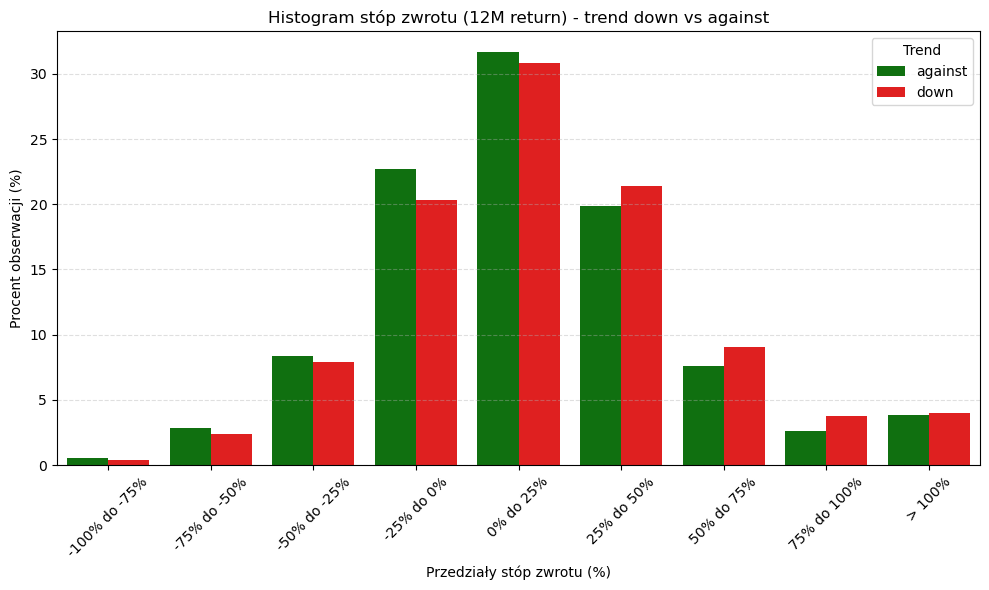

In [56]:
for col in ["1M_return", "3M_return", "12M_return"]:
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=df_hist[df_hist["period"]==col],
        x=f"{col}_bin",
        y="percent",
        hue="trend",
        palette={"down": "red", "against": "green"}
    )
    plt.xticks(rotation=45)
    plt.xlabel("Przedziały stóp zwrotu (%)")
    plt.ylabel("Procent obserwacji (%)")
    plt.title(f"Histogram stóp zwrotu ({col.replace('_',' ')}) - trend down vs against")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.legend(title="Trend")
    plt.tight_layout()
    plt.show()